# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv(r'C:\Users\mazur\data_analysis\data\yulu_rental.csv')

In [57]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [58]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Post-monsoon', 11: 'Post-monsoon'
}

df['season'] = df['month'].map(season_map)

df.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,Winter,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,Winter,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,Winter,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2


In [59]:
df[['month','season']].head(10)

,month,season
datetime,,
2011-01-01 00:00:00,1,Winter
2011-01-01 01:00:00,1,Winter
2011-01-01 02:00:00,1,Winter
2011-01-01 03:00:00,1,Winter
2011-01-01 04:00:00,1,Winter
2011-01-01 05:00:00,1,Winter
2011-01-01 06:00:00,1,Winter
2011-01-01 07:00:00,1,Winter
2011-01-01 08:00:00,1,Winter


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [60]:
s = df.shape
print(f'Дані містять {s[0]} рядків і {s[1]} колонок')
print('Дані деталізовані, 1 рядок це одне замовлення')
#df.index
df.info()

display(df.head(3))
display(df.tail(3))

Дані містять 10886 рядків і 19 колонок
Дані деталізовані, 1 рядок це одне замовлення
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  object 
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year      

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,Winter,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,Winter,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,Winter,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2012-12-19 21:00:00,Winter,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21
2012-12-19 22:00:00,Winter,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012-12-19,19,51,2,Wednesday,2012,12,22
2012-12-19 23:00:00,Winter,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012-12-19,19,51,2,Wednesday,2012,12,23


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


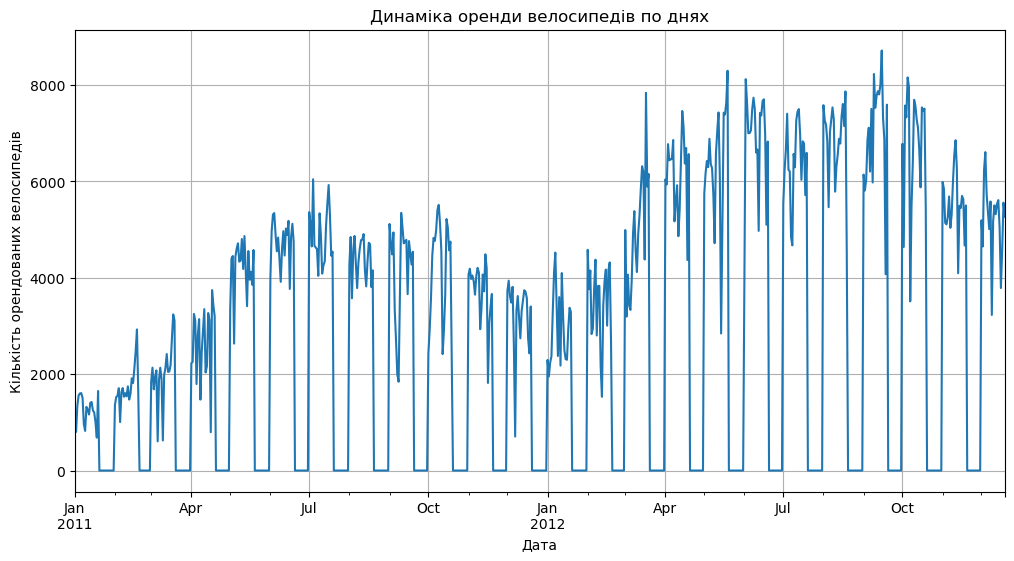

In [61]:
count = df.resample('D')['count'].sum()
count.plot.line(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів по днях',
    xlabel='Дата',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);

In [62]:
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

Графік має заломи бо є дні коли велосипеди не орендували взагалі.
Щоб позбутися заломів я би будувала графік по місяцях, а не по днях

SyntaxError: invalid syntax (851995385.py, line 3)

C:\Users\mazur\AppData\Local\Temp\ipykernel_6444\2528137300.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  count = df.resample('M')['count'].sum()


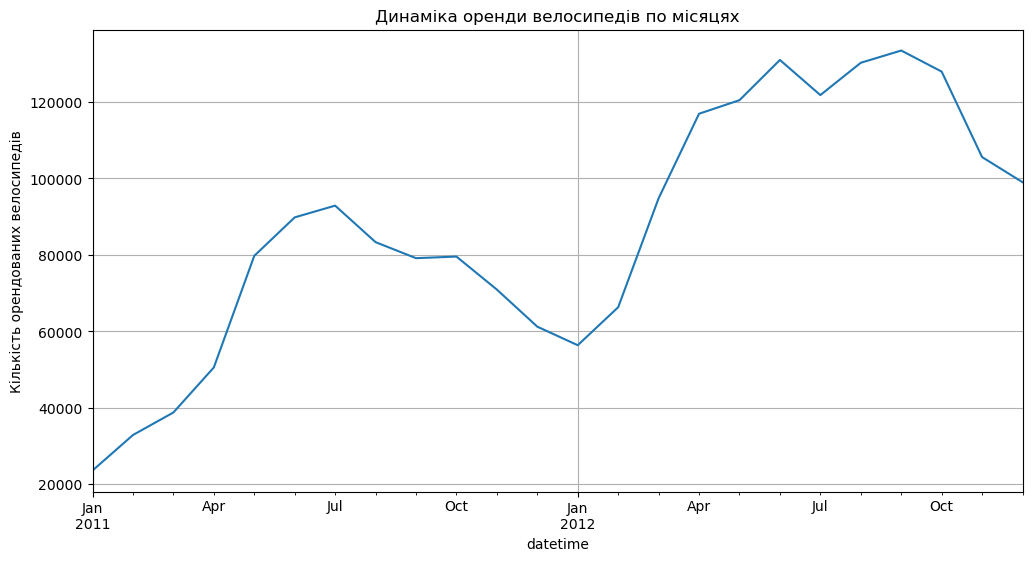

In [ ]:
count = df.resample('M')['count'].sum()
count.plot.line(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів по місяцях',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);

In [ ]:
2. Які загальні тенденції ви бачите на графіку?

Загалом ми маємо позитивну динаміку зростання оренди велосипедів, бізнес зростає. 
З квітня по жовтень найвищі показники оренди.

In [ ]:
3. Чи помітні якісь сезонні коливання?

Сезонні коливання дуже помітні:
- зростання весна
- максимальні прокати влітку
- спад осінь
- мінімальні прокати взимку

SyntaxError: invalid syntax (388562415.py, line 3)

In [ ]:
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?
Аномалій не бачу, дані корелюються відповідно до сезону



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

season
Monsoon         236.322359
Post-monsoon    210.688255
Summer          184.074210
Winter          125.753430
Name: count, dtype: float64


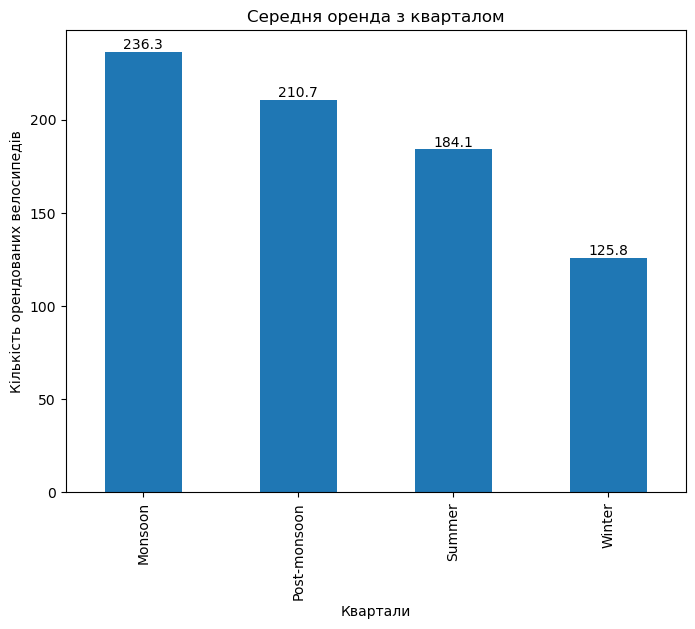

In [ ]:
avg_count = df.groupby('season')['count'].mean()
print(avg_count)

gr = avg_count.plot.bar(
    figsize=(8, 6),
    title='Середня оренда з кварталом',
    xlabel='Квартали',
    ylabel='Кількість орендованих велосипедів',
);

for el in gr.patches:
    gr.annotate(
        round(el.get_height(), 1),
        xy=(el.get_x() + el.get_width()/2, el.get_height()),
        va='bottom',
        ha='center'
    )

plt.show()

In [ ]:
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [ ]:
maxseason = avg_count.idxmax()
maxcount = avg_count.max()
print(f'Максимальна кількість оренди в сезон {maxseason}  становить {maxcount}')

Максимальна кількість оренди в сезон Monsoon  становить 236.32235939643348


In [ ]:
avg_df = (
    df.groupby('season').agg({
    'temp':'mean',
    'atemp':'mean',
    'humidity':'mean',
    'windspeed':'mean',
    'holiday':'mean',
    'workingday':'mean'
    })
    .round(1)
)

print(avg_df)

              temp  atemp  humidity  windspeed  holiday  workingday
season                                                             
Monsoon       28.4   32.2      62.8       11.7      0.0         0.7
Post-monsoon  18.1   21.5      65.1       12.2      0.1         0.7
Summer        19.1   22.7      60.2       14.4      0.0         0.7
Winter        11.8   14.6      60.3       13.1      0.0         0.7


В сезоні Monsoon найбільш сприятливі умови для катання на велосипеді:
- висока температура 
- середня вологість
- найнижчі пориви вітру     

In [ ]:
mincount = avg_count.min()
print(maxcount)
print(mincount)

difference = maxcount/mincount
print(f'Найвищий сезон відрізняється від найнищого в {difference:.1f} разів')

236.32235939643348
125.75342973674454
Найвищий сезон відрізняється від найнищого в 1.9 разів


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


month
1      90.366516
2     110.003330
3     148.169811
4     184.160616
5     219.459430
6     242.031798
7     235.325658
8     234.118421
9     233.805281
10    227.699232
11    193.677278
12    175.614035
Name: count, dtype: float64


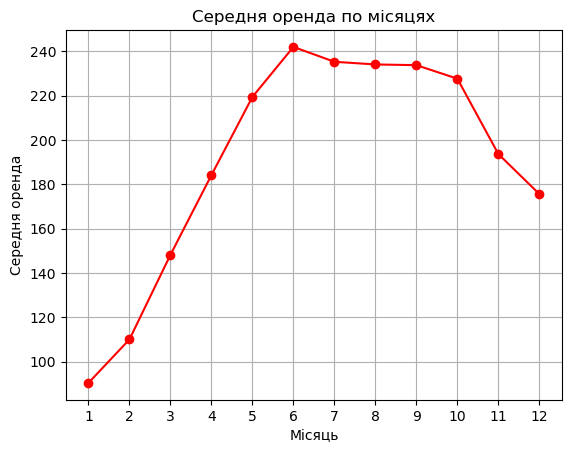

In [ ]:
avg_count_by_month = df.groupby('month')['count'].mean()

print(avg_count_by_month)

avg_count_by_month_line = avg_count_by_month.plot.line(
    xlabel = 'Місяць',
    ylabel = 'Середня оренда',
    title = 'Середня оренда по місяцях',
    color='red',
    grid = True,
    marker = 'o'
);
avg_count_by_month_line.set_xticks(range(1,13))
avg_count_by_month_line.set_xticklabels(range(1,13))

plt.show()

In [ ]:
1. Найбільша кількість оренди в 6 місяці, який входить в сезон Monsoon, що збігається з нашими попередніми дослідженями.
   Найменша кількість орендованих велосипедів 1-4 і 12 місяць, це Winter i Summer.
2. 7,8,9 місяці теж висока середня оренда, знову ж таки це сезон Monsoon.
3. Виглядає що людям найбільше подобається їздити в спекотну погоду з помірною вологістю і мінімальним вітром.


SyntaxError: invalid syntax (2839782608.py, line 1)

In [ ]:
print(avg_df)

NameError: name 'avg_df' is not defined

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

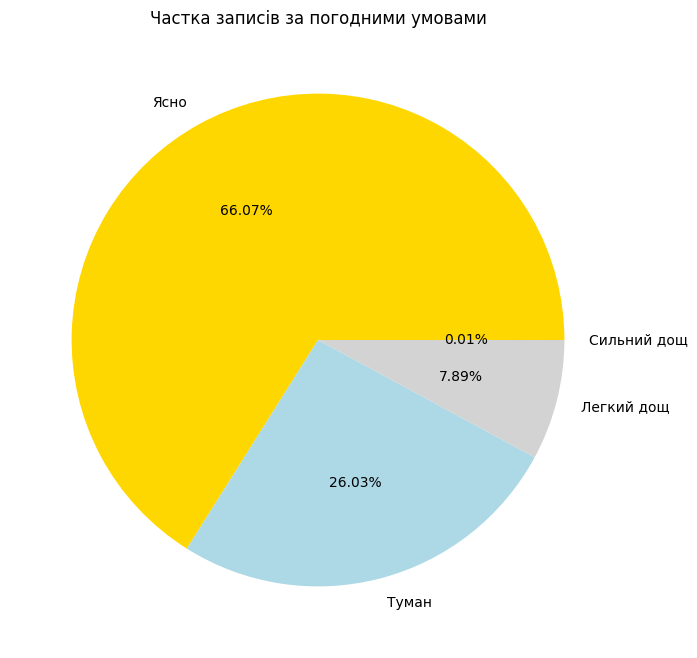

In [ ]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour'],
      dtype='object')

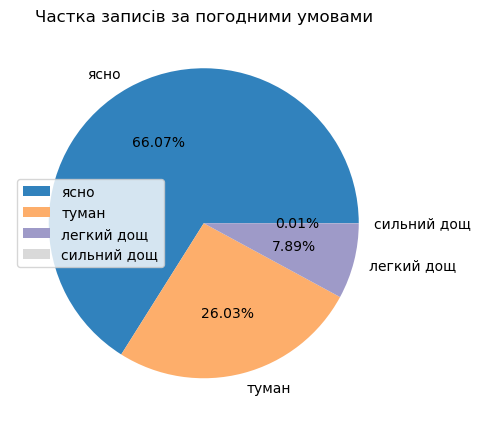

In [ ]:
pers_by_weather = df.groupby('weather')['weather'].count();

pers_by_weather.plot.pie(
    title ='Частка записів за погодними умовами',
    legend = True,
    ylabel="",
    colormap='tab20c',
    autopct='%1.2f%%',
    labels = ['ясно', 'туман', 'легкий дощ', 'сильний дощ'],
    figsize = [5, 10]
);

In [ ]:
1. Яка погода переважає в датасеті? 
В датасеті переважає ясна погода - 66% всього часу
2. Чи є дні із сильним дощем? Яка їх частка?
Є дні з сильним дощем, але їх менше 1%
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?
На попит на оренду велосипедів найбільше впливає сильний дощ, бо в цей час попит практично відсутній. 
Найкраще впливає на попит ясна поггода.

SyntaxError: invalid syntax (2835191109.py, line 1)

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [ ]:
print(df['weather'].unique())

[1 2 3 4]


Text(0.5, 0, 'Кількість оренд')

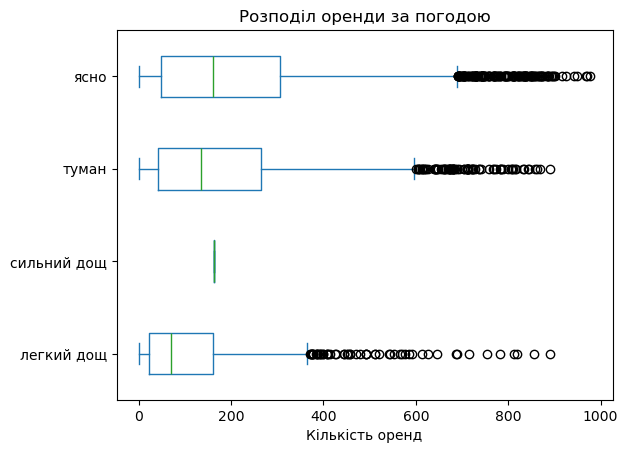

In [66]:
weather_map = {
    1: 'ясно',
    2: 'туман',
    3: 'легкий дощ',
    4: 'сильний дощ'
}

df['weather_name'] = df['weather'].map(weather_map)

df.plot.box(
    column = 'count',
    by = 'weather',
    vert = False
);
plt.title('Розподіл оренди за погодою')
plt.xlabel('Кількість оренд')

In [ ]:
1. При якій погоді найбільший розкид у кількості оренди?
Набільший розкид при ясній погоді, велика колобка і великі вуса. Трохи менших розкид при тумані.

2. Чи є викиди (outliers) в даних? При якій погоді?
Викиди є при ясній погоді, коли легкий дощ і туман. При сильному дощі оренда практично не варіюється.

3. При якій погоді медіанне значення оренди найвище?
Медіанне значення найвище при ясній погоді.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

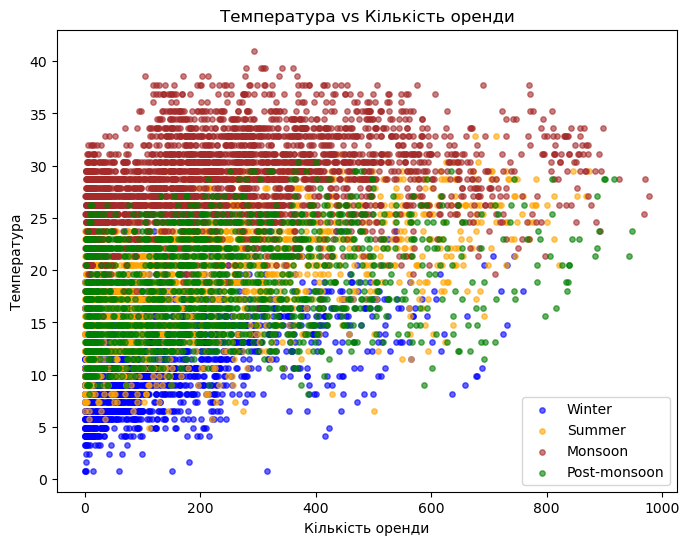

In [92]:
colors = {
    'Winter': 'blue',
    'Post-monsoon': 'green',
    'Summer': 'orange',
    'Monsoon': 'brown'
}

plt.figure(figsize=(8,6))

for s in df['season'].unique():
    subset = df[df['season'] == s]
    plt.scatter(
        subset['count'],
        subset['temp'],
        color=colors[s],
        label = s,
        alpha=0.6,
         s=15
    )

plt.xlabel('Кількість оренди')
plt.ylabel('Температура')
plt.title('Температура vs Кількість оренди')
plt.legend()
plt.show()

In [ ]:
При температурі 30-35 градусів кількість найвища, при зниженні темпаратури замовляння падають.

['Winter' 'Summer' 'Monsoon' 'Post-monsoon']


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?